<a href="https://colab.research.google.com/github/NathalieKa/Python101/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<figure>
  <IMG SRC="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d5/Fachhochschule_Südwestfalen_20xx_logo.svg/320px-Fachhochschule_Südwestfalen_20xx_logo.svg.png" WIDTH=250 ALIGN="right">
</figure>

# Einführung Machine Learning
### Sommersemester 2026
Prof. Dr. Heiner Giefers

# Datenvorverarbeitung am Beispiel Titanic

In Orange haben Sie mithilfe von Modulen wie **File**, **Impute**, **Continuize** und **Test & Score** die Titanic-Daten vorbereitet, um Klassifikationsmodelle zu trainieren.

In dieser Übung übertragen wir das Gelernte auf Python – konkret mit `pandas` und `scikit-learn`. Sie lernen dabei:
- wie man fehlende Werte erkennt und ersetzt,
- wie man kategoriale Merkmale numerisch codiert (ordinal vs. nominal),
- wie man numerische Merkmale standardisiert,
- und wie man die vorbereiteten Daten für Modelle nutzbar macht.


## Daten laden

Zunächst müssen wir die Daten laden. Als Datenstruktur bietet sich dafür ein Pandas DataFrame an.
mit `pandas.read_csv()` können wir eine CSV-Datei aus dem Internet direkt in ein DataFrame Objekt laden.

In [1]:
import pandas as pd
url = "https://raw.githubusercontent.com/fhswf/datasets/refs/heads/main/Titanic_de.csv"
df=pd.read_csv(url)
df

,ueberlebt,geschlecht,alter,geschwister_ehepartner,eltern_kinder,fahrpreis,klasse,erwachsener_mann,deck,hafen,allein
0,0,maennlich,22.0,1,0,7.2500,Dritte,True,NaN,Southampton,False
1,1,weiblich,38.0,1,0,71.2833,Erste,False,C,Cherbourg,False
2,1,weiblich,26.0,0,0,7.9250,Dritte,False,NaN,Southampton,True
3,1,weiblich,35.0,1,0,53.1000,Erste,False,C,Southampton,False
4,0,maennlich,35.0,0,0,8.0500,Dritte,True,NaN,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,maennlich,27.0,0,0,13.0000,Zweite,True,NaN,Southampton,True
887,1,weiblich,19.0,0,0,30.0000,Erste,False,B,Southampton,True
888,0,weiblich,NaN,1,2,23.4500,Dritte,False,NaN,Southampton,False
889,1,maennlich,26.0,0,0,30.0000,Erste,True,C,Cherbourg,True


Um einen ersten Eindruck über die Skalenniveaus zu erhalten, geben wir die folgende Funktion an.
Wir werden später sehen, dass wir die unterschiedlichen Merkmalstypen auch durch durch Pandas-Funktionen und Anzeigen der Daten erkennen können.

Der Text erklärt, dass man sich zunächst einen ersten Überblick über die Skalenniveaus der Daten verschaffen will – also darüber, welche Art von Merkmalen (Variablen) in einem Datensatz vorhanden sind.
Skalenniveaus sind die verschiedenen "Typen" von Daten, z.B.:


Nominal – Kategorien ohne Reihenfolge (z.B. Farben, Geschlecht)

Ordinal – Kategorien mit Reihenfolge (z.B. Schulnoten)

Metrisch – Zahlen mit echten Abständen (z.B. Alter, Gewicht)

In [2]:
def erkenne_skalenniveaus(df):
    """
    Schätzt das Skalenniveau jeder Spalte in einem pandas-DataFrame heuristisch ein und
    ordnet sie einer der folgenden vier Kategorien zu:

    1. binaer (dichotom):
       - Spalten mit genau zwei eindeutigen Werten (z. B. Ja/Nein, 0/1)

    2. metrisch:
       - Numerische Spalten mit mehr als 10 eindeutigen Werten
       - Annahme: kontinuierliche oder verhältnisskalierte Daten

    3. ordinal:
       - Numerische Spalten mit höchstens 10 eindeutigen Werten
       - Annahme: diskrete Werte mit natürlicher Reihenfolge, aber ohne metrische Interpretation

    4. nominal:
       - Alle übrigen Spalten (z. B. Strings, Kategorien ohne Reihenfolge)

    Hinweis:
    - Diese Einschätzung basiert auf Datentyp (`dtype`) und Anzahl eindeutiger Werte (`nunique()`).
    - Sie ist heuristisch und kann bei semantisch komplexen Merkmalen ungenau sein.!!!!!!!!!!!!!
    """
    nominal = []
    ordinal = []
    metrisch = []
    binaer = []

    for spalte in df.columns:
        typ = df[spalte].dtype
        unique_vals = df[spalte].nunique(dropna=True)

        if unique_vals == 2: # unique == 2, dann binär
            binaer.append(spalte)
        elif pd.api.types.is_numeric_dtype(typ):
            if unique_vals <= 10: # unique <= 10, dann ordinal
                ordinal.append(spalte)
            else:
                metrisch.append(spalte) #Mehr als 10, dann metrisch
        else:
            nominal.append(spalte) #sonst nominal (geschwister)

    print("\nVermutlich binaer (dichotom):")
    for spalte in binaer: print(f"  - {spalte} ({df[spalte].dtype})");

    print("\nVermutlich metrisch:")
    for spalte in metrisch: print(f"  - {spalte} ({df[spalte].dtype})");

    print("\nVermutlich ordinal:")
    for spalte in ordinal: print(f"  - {spalte} ({df[spalte].dtype})");

    print("\nVermutlich nominal:")
    for spalte in nominal: print(f"  - {spalte} ({df[spalte].dtype})");

erkenne_skalenniveaus(df)


Vermutlich binaer (dichotom):
  - ueberlebt (int64)
  - geschlecht (object)
  - erwachsener_mann (bool)
  - allein (bool)

Vermutlich metrisch:
  - alter (float64)
  - fahrpreis (float64)

Vermutlich ordinal:
  - geschwister_ehepartner (int64)
  - eltern_kinder (int64)

Vermutlich nominal:
  - klasse (object)
  - deck (object)
  - hafen (object)


Eine gute Übersicht über die Spalten und die zugehörigen Datentypen erhält man mit der Pandas-Funktion `info()`.
Wir sehen ebenfalls, dass es nicht immer gleich viele korrekte (nicht-Null) Werte gibt.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ueberlebt               891 non-null    int64  
 1   geschlecht              891 non-null    object 
 2   alter                   714 non-null    float64
 3   geschwister_ehepartner  891 non-null    int64  
 4   eltern_kinder           891 non-null    int64  
 5   fahrpreis               891 non-null    float64
 6   klasse                  891 non-null    object 
 7   erwachsener_mann        891 non-null    bool   
 8   deck                    203 non-null    object 
 9   hafen                   889 non-null    object 
 10  allein                  891 non-null    bool   
dtypes: bool(2), float64(2), int64(3), object(4)
memory usage: 64.5+ KB


Jede Zahl steht für die Anzahl der Einträge in der Spalte:


891 → alle 891 Passagiere haben diesen Wert → vollständig

714 → nur 714 von 891 haben ein Alter → 177 fehlen

203 → nur 203 von 891 haben ein Deck → 688 fehlen

Um die Anzahl fehlender Werte pro Merkmal genau zu untersuchen, können wir NumPy Funktionen verwenden (`.isna().sum()`).

In [4]:
df.isna().sum()

,0
ueberlebt,0
geschlecht,0
alter,177
geschwister_ehepartner,0
eltern_kinder,0
fahrpreis,0
klasse,0
erwachsener_mann,0
deck,688
hafen,2


Im Jupyter Notebook genügt die Angabe der DataFrame Variable am Ende der Zelle, um eine gekürzte Tabelle anzuzeigen.
Etwas Ähnliches kann man über die Funktion `head()` erreichen. Sie gibt die ersten Zeilen eines DataFrames aus, wobei die Anzahl der Zeilen mit dem ersten Parameter angegeben werden kann.

In [5]:
df.head(12)

,ueberlebt,geschlecht,alter,geschwister_ehepartner,eltern_kinder,fahrpreis,klasse,erwachsener_mann,deck,hafen,allein
0,0,maennlich,22.0,1,0,7.2500,Dritte,True,NaN,Southampton,False
1,1,weiblich,38.0,1,0,71.2833,Erste,False,C,Cherbourg,False
2,1,weiblich,26.0,0,0,7.9250,Dritte,False,NaN,Southampton,True
3,1,weiblich,35.0,1,0,53.1000,Erste,False,C,Southampton,False
4,0,maennlich,35.0,0,0,8.0500,Dritte,True,NaN,Southampton,True
5,0,maennlich,NaN,0,0,8.4583,Dritte,True,NaN,Queenstown,True
6,0,maennlich,54.0,0,0,51.8625,Erste,True,E,Southampton,True
7,0,maennlich,2.0,3,1,21.0750,Dritte,False,NaN,Southampton,False
8,1,weiblich,27.0,0,2,11.1333,Dritte,False,NaN,Southampton,False
9,1,weiblich,14.0,1,0,30.0708,Zweite,False,NaN,Cherbourg,False


## Fehlende Werte kompensieren

Viele Machine-Learning-Algorithmen – darunter häufig verwendete Modelle wie **Support Vector Machines (SVM)**, **logistische Regression**, **k-Nearest Neighbors (KNN)** oder auch **lineare Regressionsmodelle** – setzen voraus, dass der Eingabedatensatz **vollständig ist**. Das bedeutet: es dürfen keine fehlenden Werte (`NaN`) in den Trainingsdaten vorkommen. Andernfalls brechen viele Algorithmen mit einem Fehler ab oder liefern undefiniertes Verhalten.

Im **Titanic-Datensatz** finden sich solche fehlenden Werte insbesondere in Feldern wie dem Alter (`alter`) oder dem Passagierdeck (`deck`). Diese Lücken entstehen entweder durch unvollständige historische Aufzeichnungen oder durch bewusste Datenreduktion im Rahmen der Datenbereitstellung. Um mit diesen Lücken weiterarbeiten zu können, müssen wir sie **auffüllen** – dieser Schritt wird in der Datenvorverarbeitung als **Imputation** bezeichnet.

**Warum nicht einfach löschen?**

Eine erste naive Idee wäre, alle Zeilen mit fehlenden Werten einfach zu löschen. Das funktioniert technisch, ist aber **problematisch**, da dadurch:
- wichtige Informationen verloren gehen,
- Verzerrungen in der Verteilung entstehen können (z. B. wenn ältere Personen häufiger fehlende Werte haben),
- und ggf. der Datensatz deutlich kleiner wird.

Daher ist es in der Praxis gängiger und auch methodisch sinnvoller, **fehlende Werte zu imputieren** – also sie durch plausible Werte zu ersetzen, die auf den vorhandenen Daten basieren.

#### Für **numerische Merkmale** (metrische oder ordinale Werte):

- **Mittelwert (Mean)**: Der fehlende Wert wird durch den Durchschnitt der bekannten Werte ersetzt. Dies ist einfach und meist eine brauchbare Wahl, wenn die Verteilung symmetrisch ist und keine starken Ausreißer vorliegen.
- **Median**: Robuster gegenüber Ausreißern, da er den zentralen Wert der Verteilung nutzt. Besonders geeignet, wenn die Daten schief verteilt sind oder Extremwerte auftreten.
- Weitere Methoden (nicht hier verwendet): Regressionsbasierte Imputation, KNN-Imputation, multiple Imputation (z. B. mit `IterativeImputer`).

#### Für **kategoriale Merkmale** (nominale Variablen):

- **Modus** (häufigste Kategorie): Fehlende Werte werden durch die am häufigsten vorkommende Ausprägung ersetzt. Diese Strategie ist sinnvoll, da sie keine Annahmen über eine Reihenfolge trifft und meist stabil funktioniert.
- Alternativen wären z. B. eine eigene Kategorie `unbekannt`, oder Modell-basierte Verfahren.

#### Umsetzung mit `SimpleImputer`

In `scikit-learn` stellt das Modul `sklearn.impute` die Klasse **`SimpleImputer`** zur Verfügung. Sie erlaubt es, systematisch fehlende Werte anhand einer gewählten Strategie zu ersetzen.

Die Vorgehensweise ist:

1. **Definieren**, welche Spalten numerisch und welche kategorisch sind.
2. **Initialisieren** des Imputers mit der gewählten Strategie (`mean` oder `most_frequent`).
3. **Fit + Transform** auf die betroffenen Spalten anwenden.

Beispiel für numerische Spalten:
```python
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="mean")
df["alter"] = num_imputer.fit_transform(df[["alter"]])
````


In [6]:
from sklearn.impute import SimpleImputer


num_cols = ["alter", "fahrpreis"]
cat_cols = ["klasse", "deck", "hafen"]

num_imputer = SimpleImputer(strategy="mean")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])



# YOUR CODE HERE
#raise NotImplementedError()

## Ordinale Features kodieren

In vielen Datensätzen, so auch im Titanic-Datensatz, gibt es Merkmale, die eine **natürliche Reihenfolge** haben. Diese Merkmale nennt man **ordinal**. Typische Beispiele sind:

- Ticketklasse (`klasse`): 1. Klasse ist „besser“ als 2. Klasse, die wiederum besser ist als 3. Klasse.
- Anzahl der Geschwister/Ehepartner an Bord (`geschwister_ehepartner`)
- Anzahl der Eltern/Kinder an Bord (`eltern_kinder`)

Diese Merkmale enthalten **diskrete Werte**, die **geordnet** sind, aber keine fest definierten Abstände haben. Es macht daher **keinen Sinn**, sie wie nominale Merkmale (z. B. `deck`) mit One-Hot-Encoding zu kodieren, da so die Ordnungsinformation verloren ginge.

#### Ordinale Merkmale in numerische Werte überführen

Zur Umsetzung in Python verwenden wir einfache Integer-Kodierungen:
- Für `klasse`: Werte 1, 2, 3 bleiben erhalten – sie reflektieren bereits die Ordnung.
- Für `geschlecht`: `"weiblich"` wird zu `0`, `"männlich"` zu `1`.
- Für `lebendig`: `"nein"` → `0`, `"ja"` → `1`
- Für boolesche Werte wie `erwachsener_mann` oder `allein`: Wandlung in `int` (`False` → `0`, `True` → `1`)

Dabei nutzen wir `map()` für die gezielte Umwandlung einzelner Kategorien und `astype(int)` für die Konvertierung von booleschen Spalten.

#### Warum kein One-Hot-Encoding?

One-Hot-Encoding wäre hier **ungeeignet**, weil es aus einem geordneten Merkmal mehrere Spalten ohne Reihenfolge macht. Zum Beispiel würden die Klassen „1“, „2“ und „3“ zu drei separaten Dummy-Spalten – dabei ginge die Information verloren, dass Klasse 1 „höherwertiger“ ist als Klasse 2 oder 3.



### Umsetzung in Python

Die Spalten `klasse`, `geschwister_ehepartner`, `eltern_kinder`, `geschlecht`, `allein` und `erwachsener_mann` werden entsprechend ihres Bedeutungsinhalts numerisch kodiert.

Dabei unterscheiden wir zwei Fälle:

- **Kategorische Werte mit zwei Ausprägungen** (z. B. `"männlich"` / `"weiblich"`, `"ja"` / `"nein"`) werden mit `map()` in Zahlen überführt.
- **Boolesche Werte** wie `True` / `False` (z. B. in `allein`, `erwachsener_mann`) lassen sich direkt mit `.astype(int)` in `0`/`1` konvertieren.

**Beispiel für `map()` (Zuweisung von Zeichenketten zu Werten)**

Im folgenden Beispiel ändern wir die Spalte `seite` in einem DataFrame `df`. Alle Einträge, die den Wert `kopf` haben, werden durch eine `0`ersetzt, die Einträge mit dem Wert `zahl` durch `1`.

```python
df["seite"] = df["seite"].map({"kopf": 0, "zahl": 1})
```
**Beispiel für `astype` (Umwandlung von Boolean in int)**


Im folgenden Beispiel nehmen wir an, dass in der Spalte `gewonnen` die Boolschen Werte `True` und `False` stehen. Wir ersetzen sie durch ihre numerischen Repräsentanten `0` und `1`.

```python
df["gewonnen"] = df["gewonnen"].astype(int)
```

Ersetzen Sie in der folgenden Code-Zelle die Werte der Spalte `geschlecht` durch `0`/`1` und in der Spalte `klasse` die Werte *Erste*, *Zweite* und *Dritte* in `0/1/2`. Ändern sie den Datentyp der Werte in den Spalten `erwachsener_mann` und `allein` in den Typ `int`.

Alle anderen ordinalen Merkmale sind bereits als Zahlenwerte gespeichert.

In [7]:
df["geschlecht"] = df["geschlecht"].map({"maennlich":1,"weiblich":0})
df["klasse"] =df["klasse"].map({"Erste":0,"Zweite":1,"Dritte":2})

df["erwachsener_mann"] = df["erwachsener_mann"].astype(int)
df["allein"] = df["allein"].astype(int)


#raise NotImplementedError()

In [8]:
df

,ueberlebt,geschlecht,alter,geschwister_ehepartner,eltern_kinder,fahrpreis,klasse,erwachsener_mann,deck,hafen,allein
0,0,1,22.000000,1,0,7.2500,2,1,C,Southampton,0
1,1,0,38.000000,1,0,71.2833,0,0,C,Cherbourg,0
2,1,0,26.000000,0,0,7.9250,2,0,C,Southampton,1
3,1,0,35.000000,1,0,53.1000,0,0,C,Southampton,0
4,0,1,35.000000,0,0,8.0500,2,1,C,Southampton,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,1,27.000000,0,0,13.0000,1,1,C,Southampton,1
887,1,0,19.000000,0,0,30.0000,0,0,B,Southampton,1
888,0,0,29.699118,1,2,23.4500,2,0,C,Southampton,0
889,1,1,26.000000,0,0,30.0000,0,1,C,Cherbourg,1


## Nominale Features kodieren

Neben ordinalen Merkmalen enthält der Titanic-Datensatz auch eine Reihe **nominaler Merkmale**, d. h. Merkmale **ohne natürliche Reihenfolge**. Dazu gehören beispielsweise:

- `hafen` („Cherbourg“, „Southampton“, „Queenstown“)
- `deck` (z. B. „A“, „B“, „C“ …)

Diese Merkmale können **nicht sinnvoll numerisch skaliert** werden, da es keine sinnvolle Reihenfolge oder Abstände zwischen den Ausprägungen gibt. Daher verwenden wir hier **One-Hot-Encoding**.

#### Was macht One-Hot-Encoding?

One-Hot-Encoding erstellt für jede Ausprägung eines Merkmals eine eigene Spalte mit dem Wert `1`, wenn diese Ausprägung zutrifft, und `0` sonst. Damit sind die Merkmale für numerische Modelle nutzbar – ohne eine künstliche Ordnung anzunehmen.

Beispiel:

| rolle   |
|---------|
| Mann    |
| Frau    |
| Kind    |

wird zu:

| rolle_Frau | rolle_Kind | rolle_Mann |
|------------|------------|------------|
| 0          | 0          | 1          |
| 1          | 0          | 0          |
| 0          | 1          | 0          |

**Achtung:**
- Wenn `drop_first=True` gesetzt wird, wird **eine Dummy-Spalte weggelassen**, um **Redundanz** zu vermeiden (sog. „Dummy-Falle“).
- Wenn `dtype=int` gesetzt wird, werden statt Boolescher Werte Integers verwendet.

### Umsetzung in Python

Mit `pandas.get_dummies()` kann das bequem erledigt werden:

```python
df = pd.get_dummies(df, columns=["rolle"], drop_first=True, dtype=int)
```

Wenden Sie nun One-Hot-Encoding auf die Merkmale `hafen` und `deck`  an.
Nach dieser Transformation sind alle nominalen Merkmale als numerische Spalten vorhanden und für maschinelles Lernen verwendbar.

In [10]:
nominal_features = ["deck", "hafen"]

df = pd.get_dummies(df, columns=nominal_features, drop_first=True, dtype=int) # dtype, weil der Werte am Anfang True und False sind.

# YOUR CODE HERE
#raise NotImplementedError()

## Wertebereiche untersuchen

Bevor wir numerische Merkmale standardisieren, ist es wichtig zu prüfen, **ob die Wertebereiche der einzelnen Spalten vergleichbar sind**. Denn:

- Einige Algorithmen (z. B. KNN, SVM, Gradient Descent) sind **sensibel gegenüber unterschiedlichen Skalen**.
- Wenn ein Feature große Werte hat (z. B. `fahrpreis` mit bis zu mehreren Hundert), und ein anderes sehr kleine (z. B. `alter` im Bereich 0–80), kann das Modell **überproportional stark auf die größer skalierten Merkmale reagieren**.
- Deshalb sollten wir alle **metrischen Features** (z. B. `alter`, `fahrpreis`) vor dem Modelltraining auf ähnliche Skalen bringen.

#### Wie kann man die Skalen überprüfen?

Dazu gibt es zwei einfache Möglichkeiten:

1. **`df.describe()`**: Zeigt statistische Kennzahlen wie Mittelwert, Standardabweichung, Min/Max etc.
2. **Boxplot** mit `pandas` oder `matplotlib`: Visualisiert Verteilung, Streuung und Ausreißer – sehr hilfreich zur Vergleichbarkeit!

In [11]:
df[["alter", "fahrpreis"]].describe()

,alter,fahrpreis
count,891.000000,891.000000
mean,29.699118,32.204208
std,13.002015,49.693429
min,0.420000,0.000000
25%,22.000000,7.910400
50%,29.699118,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


Wie du die Skalen prüfen kannst
Der Text zeigt zwei einfache Werkzeuge:
df.describe() liefert dir eine statistische Zusammenfassung jeder numerischen Spalte. Du siehst dort:

count: Anzahl der vorhandenen Werte

mean: Mittelwert

std: Standardabweichung (Streuung)

min, max: kleinster und größter Wert

25%, 50%, 75%: Quartile (50% ist der Median)

*Aus diesen Zahlen kannst du sofort ablesen, ob die Skalen ähnlich sind oder nicht.*

*Obwohl die Mittelwerte ähnlich aussehen, zeigt der Vergleich von Maximum und Standardabweichung deutlich: Die Skalen sind nicht vergleichbar – Skalierung ist nötig.*


**Das Problem**

Manche Machine-Learning-Algorithmen sind empfindlich gegenüber unterschiedlichen Skalen. Wenn eine Spalte sehr große Zahlen enthält und eine andere sehr kleine, gewichtet der Algorithmus die Spalte mit den größeren Zahlen automatisch stärker – auch wenn sie inhaltlich gar nicht wichtiger ist.

**Lösung: Skalen angleichen**

Vor dem Modelltraining sollten alle metrischen Features (z. B. alter, fahrpreis) auf ähnliche Wertebereiche gebracht werden. Diesen Schritt nennt man Standardisierung oder Skalierung.


<Axes: >

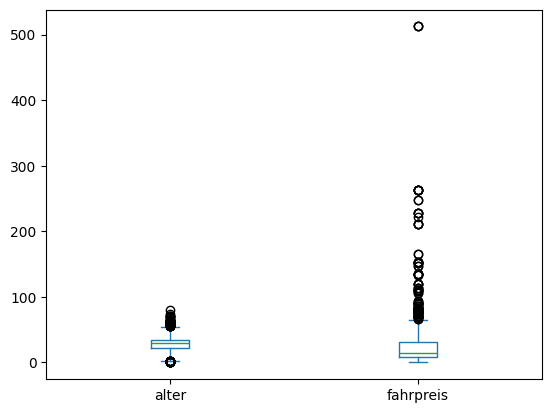

In [13]:
df[["alter", "fahrpreis"]].plot(kind="box")

## Standardisierung

Nachdem wir gesehen haben, dass die numerischen Merkmale `alter` und `fahrpreis` **sehr unterschiedliche Wertebereiche** haben, wenden wir nun eine **Standardisierung** an. Das ist ein zentraler Schritt in der Vorverarbeitung numerischer Daten – insbesondere, wenn du mit Algorithmen arbeitest, die **empfindlich auf die Skala der Eingabedaten reagieren**.

### 🧠 Was bedeutet Standardisierung?

Standardisierung ist eine **z-Transformation** der Form:

$$x' = \frac{x - \mu}{\sigma}$$

Dabei ist:
- $x$ der ursprüngliche Wert,
- $\mu$ der Mittelwert der Spalte,
- $\sigma$ die Standardabweichung der Spalte.

Ergebnis:
- **Mittelwert = 0**
- **Standardabweichung = 1**

### Warum ist Skalierung wichtig?

Viele Machine-Learning-Modelle setzen voraus, dass alle Eingabedaten vergleichbar skaliert sind:

- **SVMs** und **k-Means** verwenden Distanzmaße (z. B. euklidische Distanz).
- **Gradient Descent**-basierte Modelle wie lineare/logistische Regression oder neuronale Netze profitieren von besserer Konvergenz, wenn die Eingabedaten zentriert und skaliert sind.
- Auch bei **PCA**, **Lasso/Ridge-Regression** u. v. m. ist Standardisierung üblich und oft notwendig.


### Umsetzung in Python mit `StandardScaler`

Wir verwenden den `StandardScaler` aus `sklearn.preprocessing`. Er lernt die Mittelwerte und Standardabweichungen aus den Trainingsdaten und skaliert anschließend jede Spalte entsprechend.

Im folgenden Beispiel transformieren wir die Spalten `einkommen` und `steuersatz` im DataFrame `df`.

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[["einkommen", "steuersatz"]] = scaler.fit_transform(df[["einkommen", "steuersatz"]])
```

Diese Operation verändert nur die metrischen Spalten. Die anderen Merkmale (ordinal, binär, one-hot) bleiben unverändert und sollten nicht standardisiert werden.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[["alter", "fahrpreis"]] = scaler.fit_transform(df[["alter","fahrpreis"]])
df

# YOUR CODE HERE
#raise NotImplementedError()

,ueberlebt,geschlecht,alter,geschwister_ehepartner,eltern_kinder,fahrpreis,klasse,erwachsener_mann,allein,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,hafen_Queenstown,hafen_Southampton
0,0,1,-0.592481,1,0,-0.502445,2,1,0,0,1,0,0,0,0,0,1
1,1,0,0.638789,1,0,0.786845,0,0,0,0,1,0,0,0,0,0,0
2,1,0,-0.284663,0,0,-0.488854,2,0,1,0,1,0,0,0,0,0,1
3,1,0,0.407926,1,0,0.420730,0,0,0,0,1,0,0,0,0,0,1
4,0,1,0.407926,0,0,-0.486337,2,1,1,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,1,-0.207709,0,0,-0.386671,1,1,1,0,1,0,0,0,0,0,1
887,1,0,-0.823344,0,0,-0.044381,0,0,1,1,0,0,0,0,0,0,1
888,0,0,0.000000,1,2,-0.176263,2,0,0,0,1,0,0,0,0,0,1
889,1,1,-0.284663,0,0,-0.044381,0,1,1,0,1,0,0,0,0,0,0
